## Setup and mount Google Drive

In [72]:
# -----------------------------
# 0) Install dependencies
# -----------------------------
!pip -q install pandas numpy scikit-learn scipy
!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip -q install torch-geometric

import os
import re
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ttest_rel, wilcoxon

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv

print("Packages installed ✅")

Packages installed ✅


In [73]:
# 1) Mount Google Drive (Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
# =========================
# 1) Dataset paths (as provided)
# =========================
inspection_data_path = "/content/drive/MyDrive/DBA Folder/Capstone Project_Msc Project/Modelling/GNN_Model/Data/inspection_data.csv"
operational_data_path = "/content/drive/MyDrive/DBA Folder/Capstone Project_Msc Project/Modelling/GNN_Model/Data/operational_data.csv"
sensor_data_path      = "/content/drive/MyDrive/DBA Folder/Capstone Project_Msc Project/Modelling/GNN_Model/Data/sensor_data.csv"
string_props_path     = "/content/drive/MyDrive/DBA Folder/Capstone Project_Msc Project/Modelling/GNN_Model/Data/string_properties.csv"

print("Paths set ✅")

Paths set ✅


## 1) Load data + auto-detect key columns

In [75]:
# -----------------------------
# 2) Load CSVs
# -----------------------------
inspection_df = pd.read_csv(inspection_data_path)
oper_df       = pd.read_csv(operational_data_path)
sensor_df     = pd.read_csv(sensor_data_path)
props_df      = pd.read_csv(string_props_path)

print("Loaded shapes:")
print("inspection:", inspection_df.shape)
print("operational:", oper_df.shape)
print("sensor:", sensor_df.shape)
print("string_properties:", props_df.shape)


# -----------------------------
# 3) Helpers: column picking + segment normalization
# -----------------------------
def pick_col(df: pd.DataFrame, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"None of these columns found: {candidates}\nAvailable: {df.columns.tolist()}")
    return None

STRING_ID_CANDIDATES  = ["string_id", "ct_string_id", "ct_id", "StringID", "STRING_ID", "asset_id"]
SEGMENT_CANDIDATES    = ["segment_id", "segment_index", "segment_no", "seg_id", "SEGMENT_ID", "node_id"]
POS_M_CANDIDATES      = ["position_m", "pos_m", "depth_m", "measured_depth_m", "md_m", "MD_m"]

# Detect key columns
insp_string_col = pick_col(inspection_df, STRING_ID_CANDIDATES, required=True)
insp_seg_col    = pick_col(inspection_df, SEGMENT_CANDIDATES, required=True)   # inspection has segment_id per your columns
insp_pos_col    = pick_col(inspection_df, POS_M_CANDIDATES, required=False)

sensor_string_col = pick_col(sensor_df, STRING_ID_CANDIDATES, required=True)
sensor_seg_col    = pick_col(sensor_df, SEGMENT_CANDIDATES, required=False)
sensor_pos_col    = pick_col(sensor_df, POS_M_CANDIDATES, required=False)

oper_string_col   = pick_col(oper_df, STRING_ID_CANDIDATES, required=True)
oper_seg_col      = pick_col(oper_df, SEGMENT_CANDIDATES, required=False)
oper_pos_col      = pick_col(oper_df, POS_M_CANDIDATES, required=False)

props_string_col  = pick_col(props_df, STRING_ID_CANDIDATES, required=True)

print("\nDetected columns:")
print(" inspection: string =", insp_string_col, "| segment =", insp_seg_col, "| pos =", insp_pos_col)
print(" sensor:     string =", sensor_string_col, "| segment =", sensor_seg_col, "| pos =", sensor_pos_col)
print(" operational:string =", oper_string_col, "| segment =", oper_seg_col, "| pos =", oper_pos_col)
print(" props:      string =", props_string_col)

SEG_LEN_M = 10.0

def normalize_segment_index(series: pd.Series) -> pd.Series:
    """
    Convert segment identifiers into a consistent integer index.
    Supports:
      - pure numeric values (e.g., 457)
      - strings like 'String_A_457' -> 457
      - strings with any trailing digits -> extracted
    """
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(int)

    s = series.astype(str)

    # Extract trailing integer (e.g., 'String_A_457' -> 457)
    extracted = s.str.extract(r'(\d+)$')[0]
    if extracted.isna().mean() < 0.5:
        return extracted.astype(float).astype(int)

    # Fallback: extract ANY digit group
    extracted2 = s.str.extract(r'(\d+)')[0]
    return extracted2.astype(float).astype(int)

def ensure_segment_index(df: pd.DataFrame, string_col: str, segment_col: str=None, pos_col: str=None) -> pd.DataFrame:
    out = df.copy()

    if segment_col is not None and segment_col in out.columns:
        out["segment_index_10m"] = normalize_segment_index(out[segment_col])
        return out

    if pos_col is None or pos_col not in out.columns:
        raise ValueError("Need either a segment_id column or a position/depth column to compute segments.")

    out["segment_index_10m"] = np.floor(out[pos_col].astype(float) / SEG_LEN_M).astype(int)
    return out

Loaded shapes:
inspection: (5000, 15)
operational: (100000, 16)
sensor: (100000, 14)
string_properties: (3, 7)

Detected columns:
 inspection: string = string_id | segment = segment_id | pos = None
 sensor:     string = string_id | segment = segment_id | pos = None
 operational:string = string_id | segment = segment_id | pos = None
 props:      string = string_id


## Create consistent segment_index_10m in all datasets

In [76]:
inspection_df = ensure_segment_index(inspection_df, insp_string_col, insp_seg_col, insp_pos_col)
sensor_df     = ensure_segment_index(sensor_df, sensor_string_col, sensor_seg_col, sensor_pos_col) if (sensor_seg_col or sensor_pos_col) else None
oper_df       = ensure_segment_index(oper_df, oper_string_col, oper_seg_col, oper_pos_col) if (oper_seg_col or oper_pos_col) else None

print("\nSegment index created ✅")
print("inspection segment_index_10m sample:", inspection_df["segment_index_10m"].head().tolist())


# -----------------------------
# 5) Aggregate sensor + operational numeric features per (string, segment)
# -----------------------------
def aggregate_numeric(df: pd.DataFrame, group_cols, prefix):
    if df is None:
        raise ValueError("Sensor/Operational dataframe is None (check your segment/pos column detection).")

    # Numeric columns only (exclude group cols)
    num_cols = [c for c in df.columns if c not in group_cols and pd.api.types.is_numeric_dtype(df[c])]
    if len(num_cols) == 0:
        raise ValueError(f"No numeric columns to aggregate in {prefix}. Columns: {df.columns.tolist()}")

    # Aggregate
    agg = df.groupby(group_cols)[num_cols].agg(["mean", "std", "max"])
    agg.columns = [f"{prefix}__{c}__{stat}" for c, stat in agg.columns]
    agg = agg.reset_index()
    return agg

sensor_agg = aggregate_numeric(sensor_df, [sensor_string_col, "segment_index_10m"], "sens")
oper_agg   = aggregate_numeric(oper_df,   [oper_string_col,   "segment_index_10m"], "op")

# Merge to unified node table
nodes = pd.merge(
    sensor_agg, oper_agg,
    left_on=[sensor_string_col, "segment_index_10m"],
    right_on=[oper_string_col, "segment_index_10m"],
    how="outer"
)

# Standardize string_id column
nodes.rename(columns={sensor_string_col: "string_id"}, inplace=True)
if oper_string_col in nodes.columns and oper_string_col != "string_id":
    nodes.drop(columns=[oper_string_col], inplace=True)

print("\nUnified node feature table:", nodes.shape)


Segment index created ✅
inspection segment_index_10m sample: [1, 2, 3, 4, 5]

Unified node feature table: (4555, 68)


## Merge string-level properties (numeric only)

In [77]:
props = props_df.copy()
props.rename(columns={props_string_col: "string_id"}, inplace=True)
prop_num_cols = [c for c in props.columns if c != "string_id" and pd.api.types.is_numeric_dtype(props[c])]
props = props[["string_id"] + prop_num_cols]

nodes = pd.merge(nodes, props, on="string_id", how="left")
print("After adding string properties:", nodes.shape)


# -----------------------------
# 7) Merge inspection target: defect_length (REGRESSION)
# -----------------------------
TARGET_COL = "defect_length"
if TARGET_COL not in inspection_df.columns:
    raise ValueError(f"{TARGET_COL} not found in inspection_df. Available: {inspection_df.columns.tolist()}")

insp_targets = inspection_df[[insp_string_col, "segment_index_10m", TARGET_COL]].copy()
insp_targets.rename(columns={insp_string_col: "string_id", TARGET_COL: "y_raw"}, inplace=True)

# Aggregate if multiple inspection rows per segment
insp_targets = insp_targets.groupby(["string_id", "segment_index_10m"])["y_raw"].mean().reset_index()

# Merge into nodes
nodes = pd.merge(nodes, insp_targets, on=["string_id", "segment_index_10m"], how="left")

print("\nTarget merged ✅")
print("Nodes labeled (have defect_length):", nodes["y_raw"].notna().sum())
print("Target unique:", nodes["y_raw"].nunique(dropna=True))
print("Target std:", nodes["y_raw"].dropna().std())

After adding string properties: (4555, 72)

Target merged ✅
Nodes labeled (have defect_length): 4555
Target unique: 1409
Target std: 0.7599159949099179


## Prepare feature columns + fill missing

In [78]:
# -----------------------------
# 8) Prepare feature columns + fill missing
# -----------------------------
exclude_cols = {"string_id", "segment_index_10m", "y_raw"}
feat_cols = [c for c in nodes.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(nodes[c])]

if len(feat_cols) == 0:
    raise ValueError("No numeric feature columns found after merging!")

nodes[feat_cols] = nodes[feat_cols].replace([np.inf, -np.inf], np.nan)
nodes[feat_cols] = nodes[feat_cols].fillna(nodes[feat_cols].median(numeric_only=True))

print("\nNum features:", len(feat_cols))
print("Feature sample:", feat_cols[:10])


Num features: 70
Feature sample: ['sens__strain_gauge_reel__mean', 'sens__strain_gauge_reel__std', 'sens__strain_gauge_reel__max', 'sens__strain_gauge_gooseneck__mean', 'sens__strain_gauge_gooseneck__std', 'sens__strain_gauge_gooseneck__max', 'sens__axial_load__mean', 'sens__axial_load__std', 'sens__axial_load__max', 'sens__reel_tension__mean']


## Build PyG graphs (one per string) with chain adjacency

In [79]:
# -----------------------------
# 9) Build PyG graphs (one per string) with chain adjacency
# -----------------------------
def build_chain_edges(seg_indices: np.ndarray) -> torch.Tensor:
    # assumes g is sorted by segment_index_10m
    n = len(seg_indices)
    if n <= 1:
        return torch.empty((2, 0), dtype=torch.long)
    src, dst = [], []
    for i in range(n - 1):
        src += [i, i+1]
        dst += [i+1, i]
    return torch.tensor([src, dst], dtype=torch.long)

graphs = {}
for sid, g in nodes.groupby("string_id"):
    g = g.sort_values("segment_index_10m").reset_index(drop=True)

    x = torch.tensor(g[feat_cols].values, dtype=torch.float32)

    y = g["y_raw"].values.astype(np.float32)
    mask = ~np.isnan(y)
    y_filled = np.where(mask, y, 0.0).astype(np.float32)

    data = Data(
        x=x,
        edge_index=build_chain_edges(g["segment_index_10m"].values),
        y=torch.tensor(y_filled, dtype=torch.float32).view(-1, 1),
    )
    data.labeled_mask = torch.tensor(mask, dtype=torch.bool)
    data.string_id = sid
    graphs[sid] = data

print("\nGraphs built:", len(graphs))
example = list(graphs.keys())[0]
print("Example graph:", example, "| nodes:", graphs[example].num_nodes, "| labeled:", int(graphs[example].labeled_mask.sum()))


Graphs built: 10
Example graph: String_A | nodes: 456 | labeled: 456


## Define models (GNN vs MLP regression)

In [80]:
# -----------------------------
# 10) Define models (GNN vs MLP regression)
# -----------------------------
class GNN_Reg(nn.Module):
    def __init__(self, in_dim: int, hidden: int=64, dropout: float=0.25):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.lin = nn.Linear(hidden, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin(x)

class MLP_Reg(nn.Module):
    def __init__(self, in_dim: int, hidden: int=64, dropout: float=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x)

## LOSO training + pooled evaluation + stats

In [96]:
# -----------------------------
# 11) FULL LOSO training loop
# -----------------------------
device = "cpu"
in_dim = len(feat_cols)
EPOCHS, LR, HIDDEN, DROPOUT = 80, 1e-3, 64, 0.25

all_y, all_pred_gnn, all_pred_mlp = [], [], []
string_ids = list(graphs.keys())

for holdout in string_ids:
    train_ids = [s for s in string_ids if s != holdout]
    if int(graphs[holdout].labeled_mask.sum()) == 0: continue

    # Scaler fit on training set only
    X_train_nodes = torch.cat([graphs[s].x for s in train_ids], dim=0).numpy()
    scaler = StandardScaler().fit(X_train_nodes)

    fold = {}
    for s in train_ids + [holdout]:
        d = graphs[s]
        x_s = torch.tensor(scaler.transform(d.x.numpy()), dtype=torch.float32)
        fold[s] = Data(x=x_s, edge_index=d.edge_index, y=d.y, labeled_mask=d.labeled_mask)

    # Train GNN
    gnn = GNN_Reg(in_dim, HIDDEN, DROPOUT).to(device)
    optG = torch.optim.Adam(gnn.parameters(), lr=LR)
    loader = DataLoader([fold[s] for s in train_ids], batch_size=1, shuffle=True)
    for ep in range(EPOCHS):
        gnn.train()
        for d in loader:
            d = d.to(device)
            loss = F.mse_loss(gnn(d.x, d.edge_index)[d.labeled_mask], d.y[d.labeled_mask])
            optG.zero_grad(); loss.backward(); optG.step()

    # Train MLP
    mlp = MLP_Reg(in_dim, HIDDEN, DROPOUT).to(device)
    optM = torch.optim.Adam(mlp.parameters(), lr=LR)
    x_t = torch.cat([fold[s].x[fold[s].labeled_mask] for s in train_ids], dim=0)
    y_t = torch.cat([fold[s].y[fold[s].labeled_mask] for s in train_ids], dim=0)
    for ep in range(EPOCHS):
        mlp.train()
        loss = F.mse_loss(mlp(x_t), y_t)
        optM.zero_grad(); loss.backward(); optM.step()

    # Eval
    gnn.eval(); mlp.eval()
    d_test = fold[holdout]
    with torch.no_grad():
        pg = gnn(d_test.x, d_test.edge_index).numpy().reshape(-1)[d_test.labeled_mask]
        pm = mlp(d_test.x).numpy().reshape(-1)[d_test.labeled_mask]
        yt = d_test.y.numpy().reshape(-1)[d_test.labeled_mask]

    all_y.append(yt); all_pred_gnn.append(pg); all_pred_mlp.append(pm)
    print(f"Finished Holdout: {holdout}")

Finished Holdout: String_A
Finished Holdout: String_B
Finished Holdout: String_C
Finished Holdout: String_D
Finished Holdout: String_E
Finished Holdout: String_F
Finished Holdout: String_G
Finished Holdout: String_H
Finished Holdout: String_I
Finished Holdout: String_J


## Train GNN regression

In [84]:
# =========================
# (A) Train GNN regression
# =========================
gnn = GNN_Reg(in_dim=in_dim, hidden=HIDDEN, dropout=DROPOUT).to(device)
opt = torch.optim.Adam(gnn.parameters(), lr=LR, weight_decay=1e-4)

loader = DataLoader([fold[s] for s in train_ids], batch_size=1, shuffle=True)

for ep in range(EPOCHS):
    gnn.train()
    total = 0.0
    for d in loader:
        d = d.to(device)
        pred = gnn(d.x, d.edge_index)
        mask = d.labeled_mask
        loss = F.mse_loss(pred[mask], d.y[mask])
        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item()
    if (ep + 1) % 20 == 0:
        print(f"GNN holdout={holdout} | epoch {ep+1}/{EPOCHS} | loss={total/len(loader):.4f}")

# Evaluate GNN on holdout labeled nodes
gnn.eval()
dtest = fold[holdout].to(device)
with torch.no_grad():
    pred_g = gnn(dtest.x, dtest.edge_index).cpu().numpy().reshape(-1)

y_true = dtest.y.cpu().numpy().reshape(-1)
mask = dtest.labeled_mask.cpu().numpy()

y_true_m = y_true[mask]
pred_g_m = pred_g[mask]

GNN holdout=String_J | epoch 20/80 | loss=0.5227
GNN holdout=String_J | epoch 40/80 | loss=0.4362
GNN holdout=String_J | epoch 60/80 | loss=0.3251
GNN holdout=String_J | epoch 80/80 | loss=0.2682


## Train MLP regression

In [86]:
# =========================
# (B) Train MLP regression
# =========================
mlp = MLP_Reg(in_dim=in_dim, hidden=HIDDEN, dropout=DROPOUT).to(device)
opt2 = torch.optim.Adam(mlp.parameters(), lr=LR, weight_decay=1e-4)

x_train = torch.cat([fold[s].x for s in train_ids], dim=0)
y_train = torch.cat([fold[s].y for s in train_ids], dim=0).view(-1).numpy()
m_train = np.concatenate([fold[s].labeled_mask.numpy() for s in train_ids])

x_train_l = x_train[m_train]
y_train_l = torch.tensor(y_train[m_train], dtype=torch.float32).view(-1, 1)

for ep in range(EPOCHS):
    mlp.train()
    pred = mlp(x_train_l.to(device))
    loss = F.mse_loss(pred, y_train_l.to(device))
    opt2.zero_grad()
    loss.backward()
    opt2.step()
    if (ep + 1) % 20 == 0:
        print(f"MLP holdout={holdout} | epoch {ep+1}/{EPOCHS} | loss={loss.item():.4f}")

mlp.eval()
with torch.no_grad():
    pred_mlp = mlp(dtest.x).cpu().numpy().reshape(-1)

pred_mlp_m = pred_mlp[mask]

# Accumulate pooled
all_y.append(y_true_m)
all_pred_gnn.append(pred_g_m)
all_pred_mlp.append(pred_mlp_m)

MLP holdout=String_J | epoch 20/80 | loss=0.5830
MLP holdout=String_J | epoch 40/80 | loss=0.5627
MLP holdout=String_J | epoch 60/80 | loss=0.5518
MLP holdout=String_J | epoch 80/80 | loss=0.5441


## Pooled metrics + significance tests

In [88]:
# =========================
# 12) Pooled metrics + significance tests
# =========================
Y  = np.concatenate(all_y)
PG = np.concatenate(all_pred_gnn)
PM = np.concatenate(all_pred_mlp)

rmse_g = np.sqrt(mean_squared_error(Y, PG))
rmse_m = np.sqrt(mean_squared_error(Y, PM))

mae_g = mean_absolute_error(Y, PG)
mae_m = mean_absolute_error(Y, PM)

r2_g = r2_score(Y, PG)
r2_m = r2_score(Y, PM)

print("\n====================")
print("POOLED LOSO RESULTS (Regression target = defect_length)")
print("====================")
print(f"GNN RMSE = {rmse_g:.4f} | MLP RMSE = {rmse_m:.4f}")
print(f"GNN MAE  = {mae_g:.4f} | MLP MAE  = {mae_m:.4f}")
print(f"GNN R²   = {r2_g:.4f} | MLP R²   = {r2_m:.4f}")

# Paired tests on absolute errors
abs_err_g = np.abs(PG - Y)
abs_err_m = np.abs(PM - Y)

# Paired t-test: H1 = GNN error < MLP error -> (MLP - GNN) > 0
t_stat, p_t = ttest_rel(abs_err_m, abs_err_g)
print("\nPaired t-test on |error| (MLP - GNN):")
print(f"t = {t_stat:.4f} | p = {p_t:.6f}")

# Wilcoxon (more robust)
try:
    w_stat, p_w = wilcoxon(abs_err_m, abs_err_g, alternative="greater")
    print("\nWilcoxon signed-rank test (MLP errors > GNN errors):")
    print(f"W = {w_stat:.4f} | p = {p_w:.8f}")
except Exception as e:
    print("\nWilcoxon test failed:", e)

print("\nDone ✅")



POOLED LOSO RESULTS (Regression target = defect_length)
GNN RMSE = 0.8381 | MLP RMSE = 0.8103
GNN MAE  = 0.4148 | MLP MAE  = 0.4579
GNN R²   = -0.1004 | MLP R²   = -0.0286

Paired t-test on |error| (MLP - GNN):
t = 4.2385 | p = 0.000027

Wilcoxon signed-rank test (MLP errors > GNN errors):
W = 67639.0000 | p = 0.00000001

Done ✅


## VISUALIZATIONS

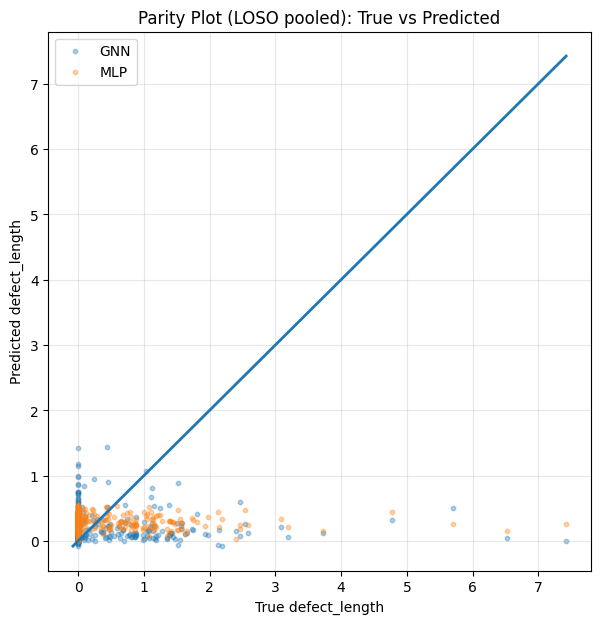

In [89]:
# ============================================================
# VISUALIZATIONS (add these cells AFTER you have Y, PG, PM)
# Assumes you already computed:
#   Y  = true defect_length (pooled LOSO, labeled nodes)
#   PG = GNN predictions
#   PM = MLP predictions
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Parity plot: True vs Pred (GNN and MLP)
# -----------------------------
plt.figure(figsize=(7,7))
plt.scatter(Y, PG, alpha=0.35, label="GNN", s=10)
plt.scatter(Y, PM, alpha=0.35, label="MLP", s=10)
mn = float(np.min([Y.min(), PG.min(), PM.min()]))
mx = float(np.max([Y.max(), PG.max(), PM.max()]))
plt.plot([mn, mx], [mn, mx], linewidth=2)  # 1:1 line (no explicit color)
plt.xlabel("True defect_length")
plt.ylabel("Predicted defect_length")
plt.title("Parity Plot (LOSO pooled): True vs Predicted")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

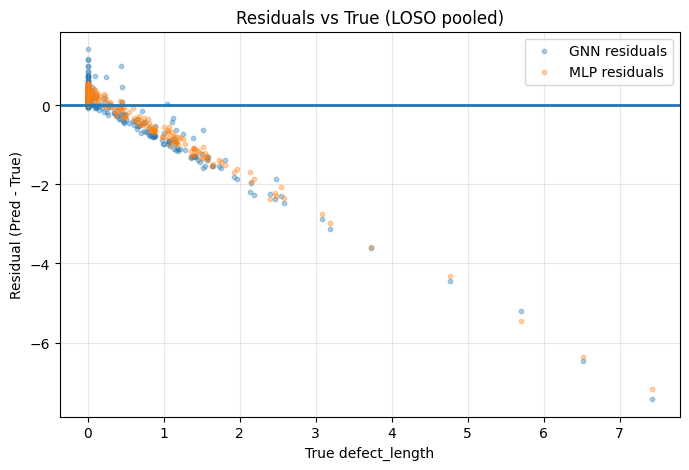

In [90]:
# -----------------------------
# 2) Residual plot: residuals vs true
# -----------------------------
res_g = PG - Y
res_m = PM - Y

plt.figure(figsize=(8,5))
plt.scatter(Y, res_g, alpha=0.35, label="GNN residuals", s=10)
plt.scatter(Y, res_m, alpha=0.35, label="MLP residuals", s=10)
plt.axhline(0, linewidth=2)  # zero residual reference
plt.xlabel("True defect_length")
plt.ylabel("Residual (Pred - True)")
plt.title("Residuals vs True (LOSO pooled)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

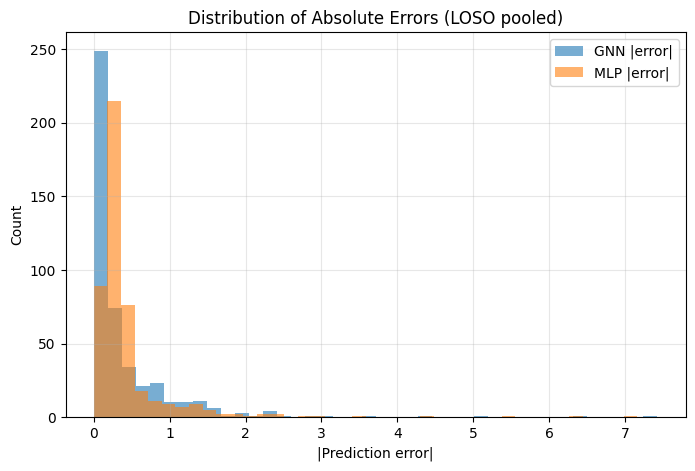

In [91]:
# -----------------------------
# 3) Error distributions: histogram of absolute errors
# -----------------------------
abs_err_g = np.abs(PG - Y)
abs_err_m = np.abs(PM - Y)

plt.figure(figsize=(8,5))
plt.hist(abs_err_g, bins=40, alpha=0.6, label="GNN |error|")
plt.hist(abs_err_m, bins=40, alpha=0.6, label="MLP |error|")
plt.xlabel("|Prediction error|")
plt.ylabel("Count")
plt.title("Distribution of Absolute Errors (LOSO pooled)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

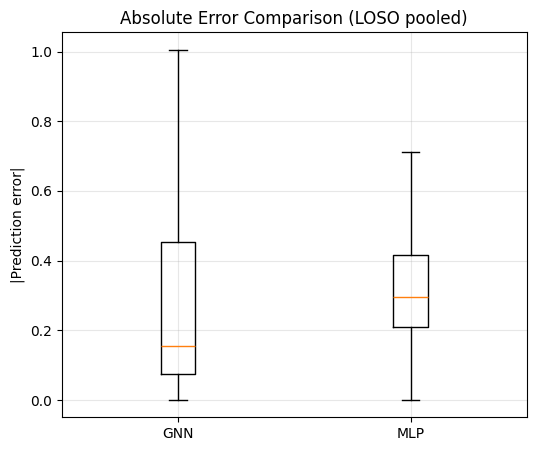

In [92]:
# -----------------------------
# 4) Boxplot: absolute errors side-by-side (quick comparison)
# -----------------------------
plt.figure(figsize=(6,5))
plt.boxplot([abs_err_g, abs_err_m], labels=["GNN", "MLP"], showfliers=False)
plt.ylabel("|Prediction error|")
plt.title("Absolute Error Comparison (LOSO pooled)")
plt.grid(True, alpha=0.3)
plt.show()


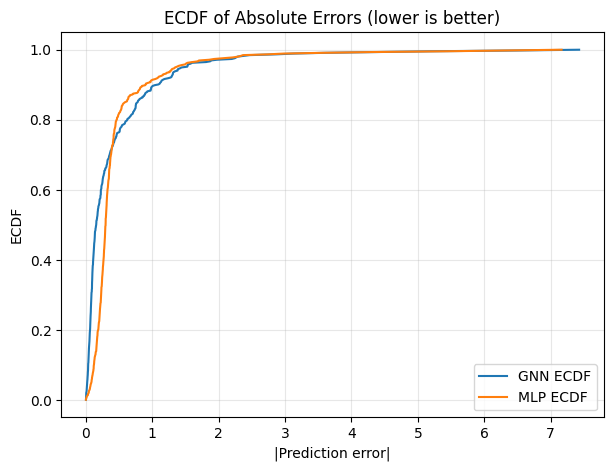

In [97]:
# -----------------------------
# 5) CDF plot: which model has lower errors more often
# -----------------------------
def ecdf(a):
    a = np.sort(a)
    y = np.arange(1, len(a)+1) / len(a)
    return a, y

xg, yg = ecdf(abs_err_g)
xm, ym = ecdf(abs_err_m)

plt.figure(figsize=(7,5))
plt.plot(xg, yg, label="GNN ECDF")
plt.plot(xm, ym, label="MLP ECDF")
plt.xlabel("|Prediction error|")
plt.ylabel("ECDF")
plt.title("ECDF of Absolute Errors (lower is better)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()